In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score

In [ ]:
df = pd.read_csv("/content/single_genre_artists.csv")
df.head(10)

,id_songs,name_song,popularity_songs,duration_ms,explicit,id_artists,release_date,danceability,energy,key,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists
0,0IA0Hju8CAgYfV1hwhidBH,La Java,0,161427,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.563,0.184,4,...,0.993,0.000016,0.3250,0.654,133.088,3,5078.0,['vintage chanson'],Mistinguett,22
1,1b8HZQCqcqwbzlA1jRTp6E,En Douce,0,223440,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.427,0.180,10,...,0.989,0.000000,0.1280,0.431,78.459,3,5078.0,['vintage chanson'],Mistinguett,22
2,5d5gQxHwYovxR5pqETOIAa,J'en Ai Marre,0,208267,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.511,0.206,0,...,0.995,0.000000,0.4180,0.481,70.443,4,5078.0,['vintage chanson'],Mistinguett,22
3,1EO65UEEPfy7CR0NK2sDxy,Ils n'ont pas ca,0,161933,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.676,0.467,9,...,0.991,0.000000,0.2190,0.726,129.775,4,5078.0,['vintage chanson'],Mistinguett,22
4,6a58gXSgqbIsXUhVZ6ZJqe,La belote,0,167973,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.650,0.298,9,...,0.991,0.000000,0.3730,0.844,75.950,4,5078.0,['vintage chanson'],Mistinguett,22
5,6sVxCBvLSd9PZA7prJn53O,Oh mademoiselle,0,158693,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.671,0.454,10,...,0.988,0.000000,0.3180,0.852,121.611,4,5078.0,['vintage chanson'],Mistinguett,22
6,3S9RAJj909UR6oOfaGxwad,Il m'a vue nue,0,196507,0,4AxgXfD7ISvJSTObqm4aIE,1925,0.515,0.249,4,...,0.994,0.000011,0.3140,0.592,72.791,4,5078.0,['vintage chanson'],Mistinguett,22
7,3vuypSGFgGT7JKJiWPJURp,Mon Bus'ness,0,172840,0,4AxgXfD7ISvJSTObqm4aIE,1925,0.415,0.330,0,...,0.978,0.000000,0.3200,0.719,72.960,4,5078.0,['vintage chanson'],Mistinguett,22
8,50gOBrK00pGazhLXGMEqwc,Ça c'est Paris,0,172987,0,4AxgXfD7ISvJSTObqm4aIE,1925,0.582,0.371,4,...,0.994,0.000647,0.0937,0.760,128.547,4,5078.0,['vintage chanson'],Mistinguett,22
9,3k4N13FLmeIcETs5zwxnvd,Le Fado,0,154733,0,4AxgXfD7ISvJSTObqm4aIE,1926,0.537,0.383,1,...,0.992,0.000004,0.1440,0.639,136.825,4,5078.0,['vintage chanson'],Mistinguett,22


In [ ]:
df.shape

(95837, 23)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95837 entries, 0 to 95836
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_songs            95837 non-null  object 
 1   name_song           95837 non-null  object 
 2   popularity_songs    95837 non-null  int64  
 3   duration_ms         95837 non-null  int64  
 4   explicit            95837 non-null  int64  
 5   id_artists          95837 non-null  object 
 6   release_date        95837 non-null  object 
 7   danceability        95837 non-null  float64
 8   energy              95837 non-null  float64
 9   key                 95837 non-null  int64  
 10  loudness            95837 non-null  float64
 11  mode                95837 non-null  int64  
 12  speechiness         95837 non-null  float64
 13  acousticness        95837 non-null  float64
 14  instrumentalness    95837 non-null  float64
 15  liveness            95837 non-null  float64
 16  vale

In [ ]:
df.describe()

,popularity_songs,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,popularity_artists
count,95837.000000,9.583700e+04,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,9.583700e+04,95837.000000
mean,26.066394,2.087320e+05,0.029644,0.586853,0.541083,5.196782,-10.157862,0.648069,0.168832,0.458989,0.082145,0.224916,0.574281,117.539870,3.851362,1.979919e+05,42.819329
std,16.254133,1.177526e+05,0.169604,0.155422,0.236304,3.534923,4.748798,0.477575,0.275417,0.330416,0.232440,0.185829,0.248126,30.190399,0.544406,7.807520e+05,20.897833
min,0.000000,6.373000e+03,0.000000,0.000000,0.000020,0.000000,-50.174000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000
25%,13.000000,1.573330e+05,0.000000,0.488000,0.365000,2.000000,-12.723000,0.000000,0.034100,0.133000,0.000000,0.100000,0.378000,94.829000,4.000000,2.563000e+03,28.000000
50%,26.000000,2.040000e+05,0.000000,0.605000,0.542000,5.000000,-9.397000,1.000000,0.046200,0.453000,0.000004,0.149000,0.589000,116.595000,4.000000,1.595600e+04,40.000000
75%,37.000000,2.502670e+05,0.000000,0.700000,0.727000,8.000000,-6.692000,1.000000,0.103000,0.759000,0.001300,0.302000,0.780000,135.975000,4.000000,8.495100e+04,56.000000
max,98.000000,4.800118e+06,1.000000,0.991000,1.000000,11.000000,5.376000,1.000000,0.968000,0.996000,1.000000,0.997000,1.000000,239.906000,5.000000,2.802643e+07,95.000000


In [ ]:
df.columns

Index(['id_songs', 'name_song', 'popularity_songs', 'duration_ms', 'explicit',
       'id_artists', 'release_date', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'time_signature', 'followers', 'genres',
       'name_artists', 'popularity_artists'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
id_songs,0
name_song,0
popularity_songs,0
duration_ms,0
explicit,0
id_artists,0
release_date,0
danceability,0
energy,0
key,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
columns_to_drop = [
    'id_songs',
    'name_song',
    'id_artists',
    'name_artists'
]

df = df.drop(columns=columns_to_drop, errors='ignore')

In [ ]:
df = df.dropna()

In [ ]:
features = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo',
    'duration_ms'
]

X = df[features]

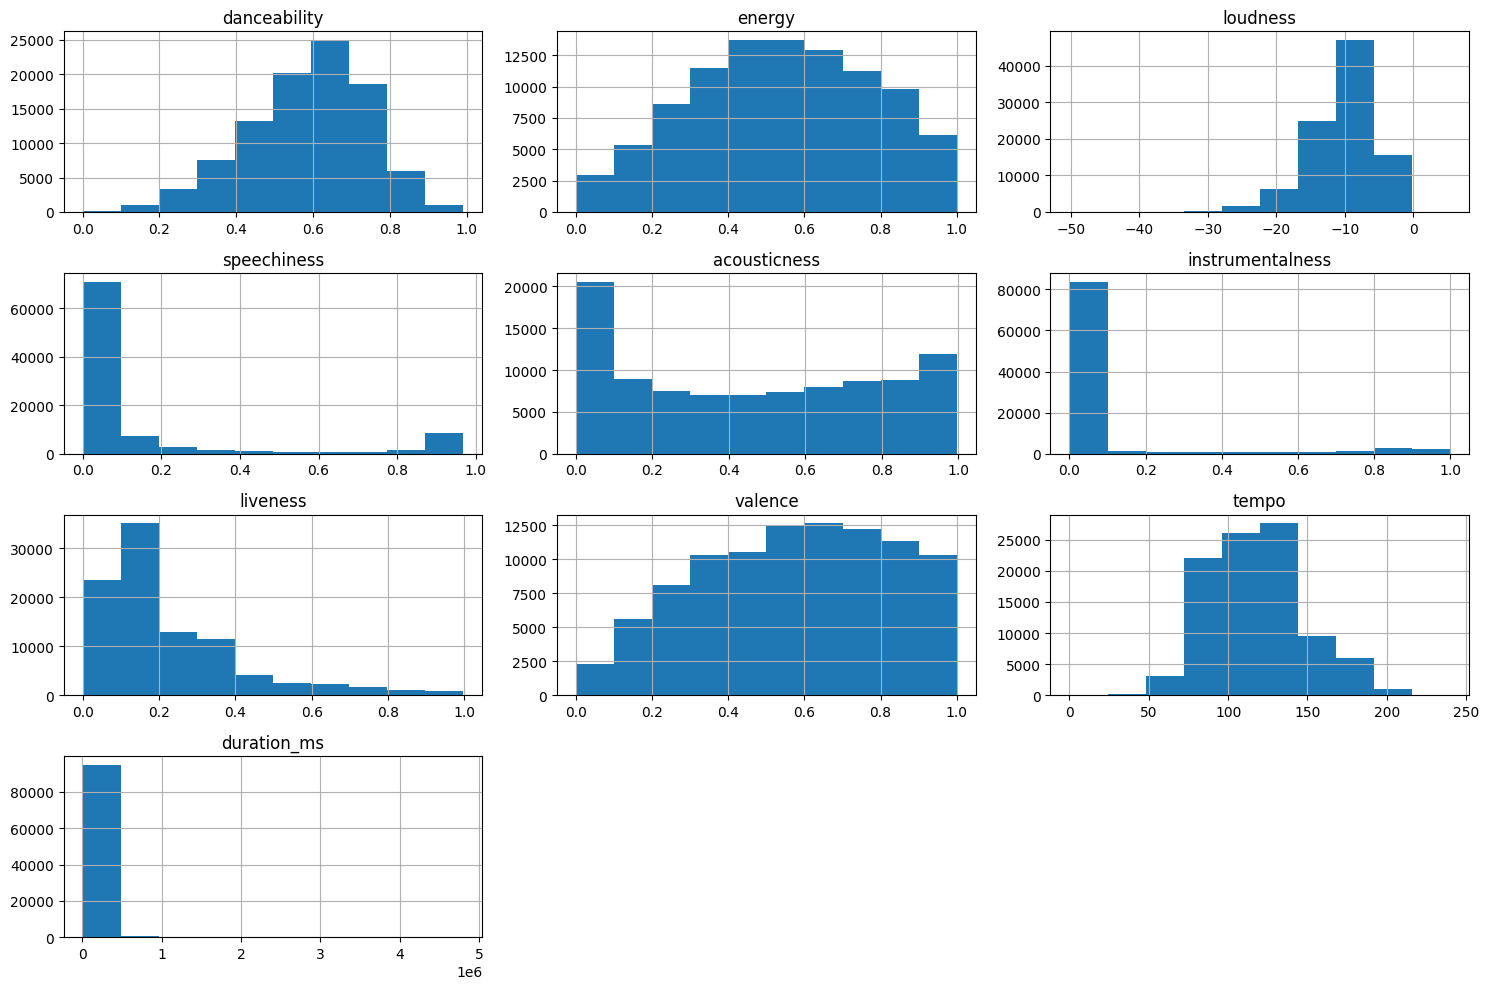

In [ ]:
X.hist(figsize=(15,10))
plt.tight_layout()
plt.show()

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
inertia = []

K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

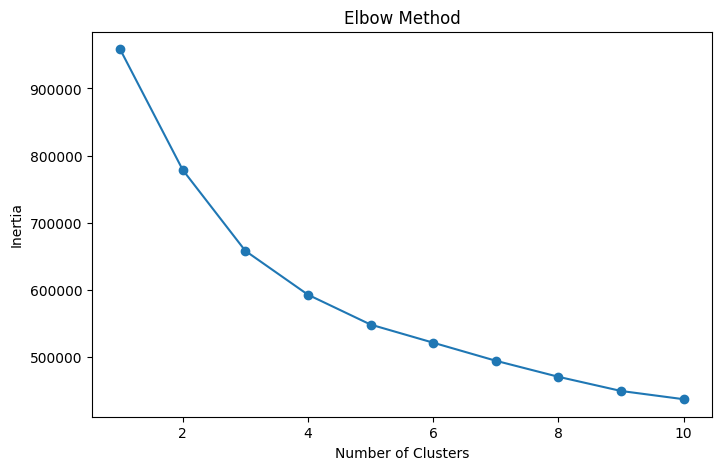

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(K, inertia, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()

In [ ]:
sil_score = silhouette_score(X_scaled, clusters)

print("Silhouette Score:", sil_score)

Silhouette Score: 0.2424014174066183


In [ ]:
db_score = davies_bouldin_score(X_scaled, clusters)

print("Davies-Bouldin Score:", db_score)

Davies-Bouldin Score: 1.5699416879877057


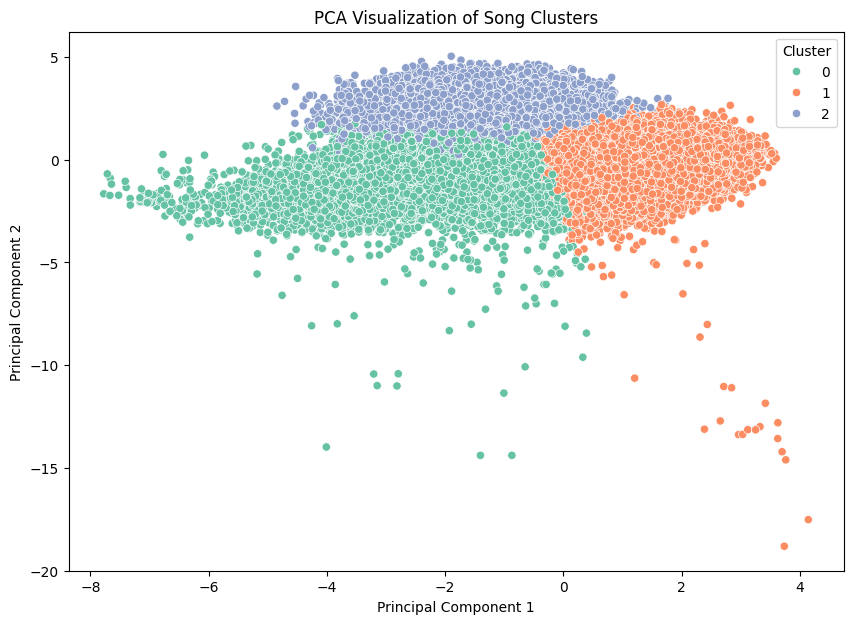

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA

# PCA transformation
pca = PCA(n_components=2)

pca_components = pca.fit_transform(X_scaled)

# Create dataframe
pca_df = pd.DataFrame(
    data=pca_components,
    columns=['PC1', 'PC2']
)

# Add cluster labels
pca_df['Cluster'] = clusters

# Plot
plt.figure(figsize=(10,7))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set2',
    data=pca_df
)

plt.title("PCA Visualization of Song Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

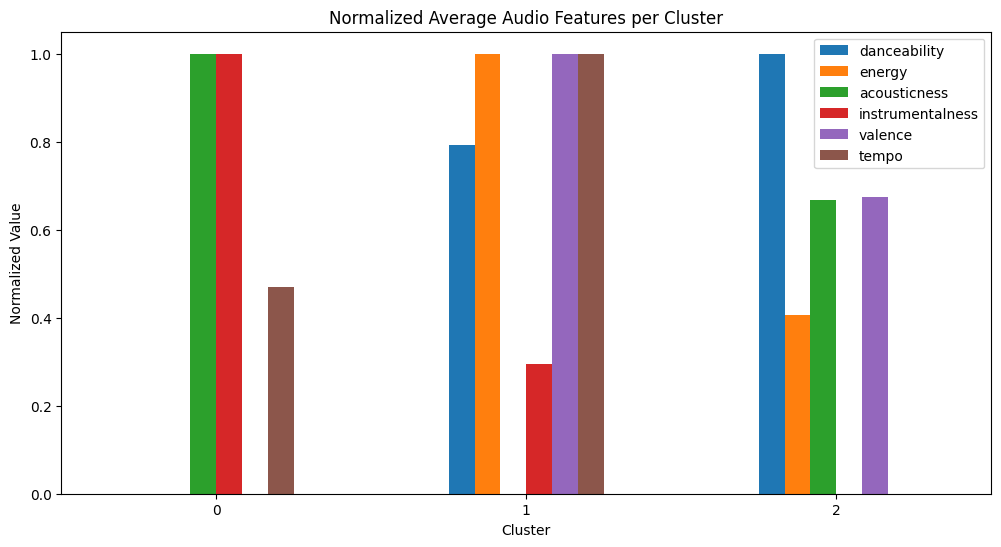

In [ ]:
from sklearn.preprocessing import MinMaxScaler

cluster_summary = df.groupby('Cluster').mean(numeric_only=True)

features = [
    'danceability',
    'energy',
    'acousticness',
    'instrumentalness',
    'valence',
    'tempo'
]

scaler = MinMaxScaler()

scaled_features = scaler.fit_transform(cluster_summary[features])

scaled_df = pd.DataFrame(
    scaled_features,
    columns=features,
    index=cluster_summary.index
)


scaled_df.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Normalized Average Audio Features per Cluster")

plt.ylabel("Normalized Value")

plt.xticks(rotation=0)

plt.show()

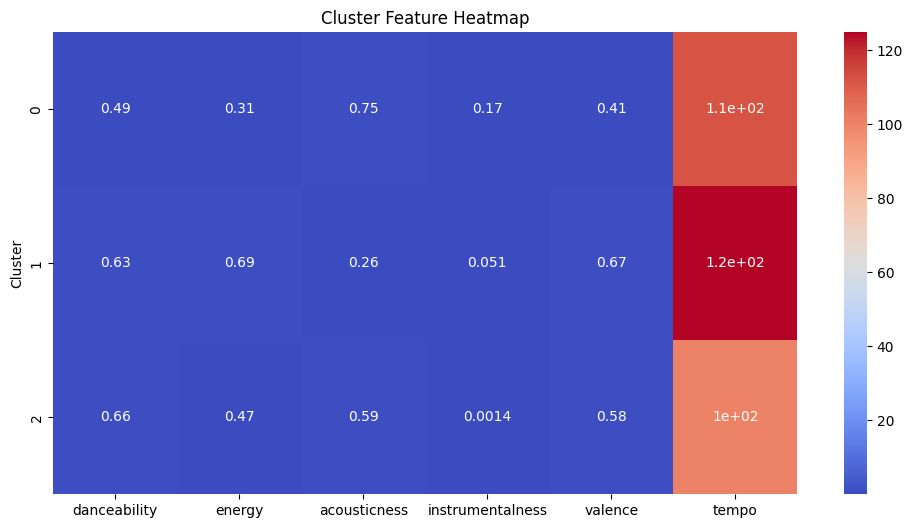

In [ ]:
plt.figure(figsize=(12,6))

sns.heatmap(
    cluster_summary[features],
    annot=True,
    cmap='coolwarm'
)

plt.title("Cluster Feature Heatmap")

plt.show()

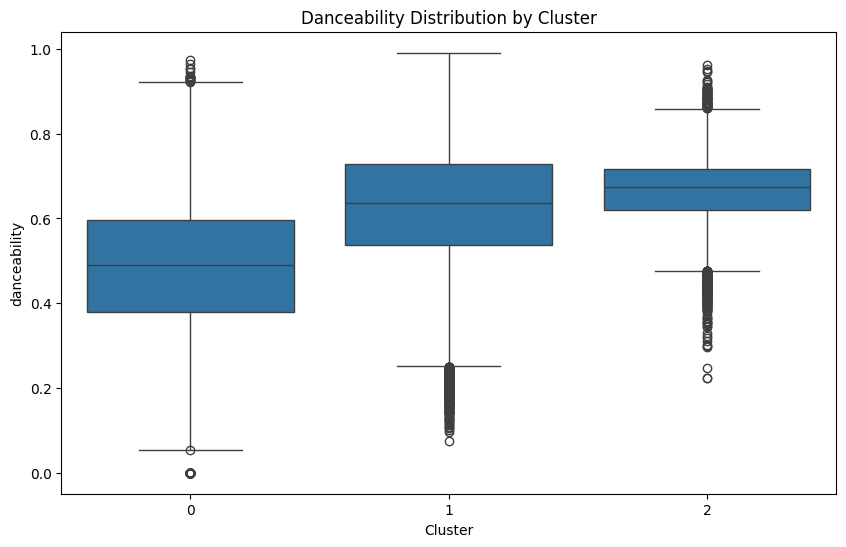

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='Cluster',
    y='danceability',
    data=df
)

plt.title("Danceability Distribution by Cluster")

plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(X_scaled)
df['Cluster'] = clusters

In [ ]:
print(df['Cluster'].value_counts())

Cluster
1    52560
0    30762
2    12515
Name: count, dtype: int64


In [ ]:
cluster_summary = df.groupby('Cluster')[features].mean()

print(cluster_summary)

         danceability    energy   loudness  speechiness  acousticness  \
Cluster                                                                 
0            0.486242  0.311018 -13.208988     0.060103      0.749539   
1            0.627309  0.693465  -7.608616     0.075061      0.258713   
2            0.664254  0.466617 -13.364383     0.829908      0.585922   

         instrumentalness  liveness   valence       tempo    duration_ms  
Cluster                                                                   
0                0.168760  0.182065  0.413047  111.933323  223500.904818  
1                0.050681  0.199854  0.666324  124.905464  226568.204680  
2                0.001384  0.435498  0.584036  100.387090   97522.338234  


In [ ]:
cluster_names = {
    0: 'Party Songs',
    1: 'Chill Acoustic',
    2: 'Instrumental'
}

df['Cluster_Name'] = df['Cluster'].map(cluster_names)

In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=5)

db_clusters = dbscan.fit_predict(X_scaled)

df['DBSCAN_Cluster'] = db_clusters

In [ ]:
df.to_csv("amazon_music_clustered_songs.csv", index=False)